# ArcFace Loss (Additive Angular Margin Loss)

# Распознавание лиц: Cross-Entropy vs ArcFace

Цель ноутбука - обучить модель классификации лиц двумя способами и сравнить их:

1. Baseline на обычном **Cross-Entropy** loss.
2. То же самое, но с **ArcFace**  головой поверх эмбеддингов.

В качестве данных используются лица, выровненные на предыдущем этапе - `aligned_dataset.csv` и
`faces_aligned`.


## Импорты и настройки

In [1]:
import os, math, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T

SEED = 1234
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print('device:', device)


device: mps


## Данные

Берём CSV, полученный на этапе выравнивания лиц (`aligned_dataset.csv`):
колонки `image_id`, `aligned_path`. Изображения уже приведены
к 112×112 и выровнены. И добовляем `person_id`, из `dentity_CelebA.txt` (`label`). 


In [2]:
df_identity = pd.read_csv('../annotation/identity_CelebA.txt',
    sep=r'\s+',
    names=['image_id', 'label']
)
df_attrs = pd.read_csv('../annotation/list_attr_celeba.txt')

print(f'Всего изображений: {len(df_identity)}')
print(f'Уникальных личностей: {df_identity["label"].nunique()}')
df_identity.head()

Всего изображений: 202599
Уникальных личностей: 10177


,image_id,label
0,000001.jpg,2880
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
4,000005.jpg,9295


In [3]:
ALIGNED_CSV = '../annotation/aligned_dataset.csv'

df_faces = pd.read_csv(ALIGNED_CSV)
df_faces

,image_id,aligned_path
0,119045.jpg,../faces_aligned/119045.jpg
1,136097.jpg,../faces_aligned/136097.jpg
2,153775.jpg,../faces_aligned/153775.jpg
3,058465.jpg,../faces_aligned/058465.jpg
4,085182.jpg,../faces_aligned/085182.jpg
...,...,...
9995,048622.jpg,../faces_aligned/048622.jpg
9996,028141.jpg,../faces_aligned/028141.jpg
9997,029610.jpg,../faces_aligned/029610.jpg
9998,072869.jpg,../faces_aligned/072869.jpg


In [4]:
df_faces = df_faces.merge(df_identity.rename(columns={'label': 'person_id'}), on='image_id', how='left')
df_faces

,image_id,aligned_path,person_id
0,119045.jpg,../faces_aligned/119045.jpg,7426
1,136097.jpg,../faces_aligned/136097.jpg,7426
2,153775.jpg,../faces_aligned/153775.jpg,7426
3,058465.jpg,../faces_aligned/058465.jpg,7426
4,085182.jpg,../faces_aligned/085182.jpg,7426
...,...,...,...
9995,048622.jpg,../faces_aligned/048622.jpg,10136
9996,028141.jpg,../faces_aligned/028141.jpg,10136
9997,029610.jpg,../faces_aligned/029610.jpg,10136
9998,072869.jpg,../faces_aligned/072869.jpg,10136


In [5]:

print(f'Всего изображений: {len(df_faces):,}')
print(f'Всего личностей:   {df_faces["person_id"].nunique():,}')
df_faces.head()


Всего изображений: 10,000
Всего личностей:   500


,image_id,aligned_path,person_id
0,119045.jpg,../faces_aligned/119045.jpg,7426
1,136097.jpg,../faces_aligned/136097.jpg,7426
2,153775.jpg,../faces_aligned/153775.jpg,7426
3,058465.jpg,../faces_aligned/058465.jpg,7426
4,085182.jpg,../faces_aligned/085182.jpg,7426


### Разбиение на train / val

Важный момент: для **классификации**  в train и val должны
присутствовать **одни и те же классы** - иначе на val сеть будет пытаться
распознать людей, которых никогда не видела. Поэтому делим **изображения**
каждого человека на train/val (не самих людей), в пропорции 80/20.


In [6]:
from sklearn.model_selection import train_test_split
VAL_FRACTION = 0.2
train_rows, val_rows = [], []
for _, group in df_faces.groupby('person_id'):
    idx = group.index.to_numpy()

    if len(idx) == 1:
        val_rows.extend(idx)
        continue

    train_idx, val_idx = train_test_split(
        idx,
        test_size=VAL_FRACTION,
        random_state=SEED
    )

    train_rows.extend(train_idx)
    val_rows.extend(val_idx)

df_train_faces = df_faces.loc[train_rows].reset_index(drop=True)
df_val_faces = df_faces.loc[val_rows].reset_index(drop=True)

# person_id в class_id
df_train_faces['class_id'] = df_train_faces['person_id'].map(
    {p: i for i, p in enumerate(sorted(df_faces['person_id'].unique()))}
)

df_val_faces['class_id'] = df_val_faces['person_id'].map(
    {p: i for i, p in enumerate(sorted(df_faces['person_id'].unique()))}
)

NUM_CLASSES = 10000

print(f'Классов: {NUM_CLASSES}')
print(f'Train:   {len(df_train_faces)}')
print(f'Val:     {len(df_val_faces)}')

Классов: 10000
Train:   8000
Val:     2000


делим по классам т.к. в обоих выборках должен быть одни и теже классы

In [7]:
df_train_faces

,image_id,aligned_path,person_id,class_id
0,145590.jpg,../faces_aligned/145590.jpg,1,0
1,142586.jpg,../faces_aligned/142586.jpg,1,0
2,033490.jpg,../faces_aligned/033490.jpg,1,0
3,049381.jpg,../faces_aligned/049381.jpg,1,0
4,117150.jpg,../faces_aligned/117150.jpg,1,0
...,...,...,...,...
7995,007947.jpg,../faces_aligned/007947.jpg,10147,499
7996,142982.jpg,../faces_aligned/142982.jpg,10147,499
7997,044099.jpg,../faces_aligned/044099.jpg,10147,499
7998,027140.jpg,../faces_aligned/027140.jpg,10147,499


In [8]:
df_val_faces

,image_id,aligned_path,person_id,class_id
0,067807.jpg,../faces_aligned/067807.jpg,1,0
1,056279.jpg,../faces_aligned/056279.jpg,1,0
2,142874.jpg,../faces_aligned/142874.jpg,1,0
3,027827.jpg,../faces_aligned/027827.jpg,1,0
4,121279.jpg,../faces_aligned/121279.jpg,8,1
...,...,...,...,...
1995,028141.jpg,../faces_aligned/028141.jpg,10136,498
1996,060321.jpg,../faces_aligned/060321.jpg,10147,499
1997,068943.jpg,../faces_aligned/068943.jpg,10147,499
1998,004770.jpg,../faces_aligned/004770.jpg,10147,499


##  Dataset и трансформации

При создании датасета предется сделать апскейл изображений до 224 на 224 пикселя т.к. EfficientNet-B0 уменьшает вход в 32 раза.

In [9]:
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Аугментация
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

eval_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class FaceRecogDataset(Dataset):

    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['aligned_path']).convert('RGB')
        img = self.transform(img)
        return img, int(row['class_id'])


BATCH_SIZE = 64
NUM_WORKERS = 0 

ds_train = FaceRecogDataset(df_train_faces, train_tfm)
ds_val   = FaceRecogDataset(df_val_faces,   eval_tfm)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Батчей: train={len(dl_train)}  val={len(dl_val)}')


Батчей: train=125  val=32


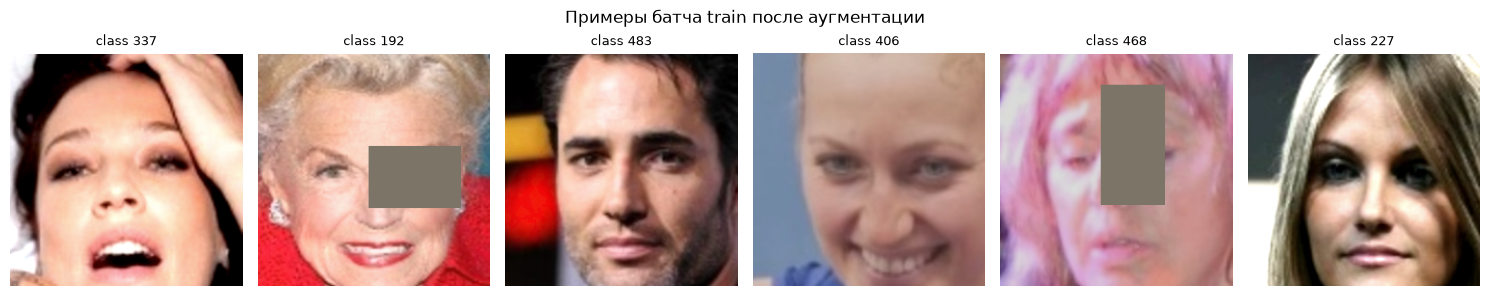

In [10]:

xb, yb = next(iter(dl_train))

def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t*s + m).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(denorm(xb[i]))
    ax.set_title(f'class {yb[i].item()}', fontsize=9)
    ax.axis('off')
plt.suptitle('Примеры батча train после аугментации')
plt.tight_layout()
plt.show()


##  Выбор модели

**Backbone: EfficientNet-B0, предобученный на ImageNet.**

EfficientNet-B0 даёт лучшее соотношение качество/стоимость среди лёгких.





In [11]:
import torch.nn as nn
from torchvision import models

EMB_DIM = 512 # длина вектора признаков


class FaceBackbone(nn.Module):

    def __init__(self, emb_dim=EMB_DIM, pretrained=True, dropout=0.3):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        net = models.efficientnet_b0(weights=weights)

        in_features = net.classifier[1].in_features
        net.classifier = nn.Identity()
        self.net = net

        self.neck = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, emb_dim),
            nn.BatchNorm1d(emb_dim),
        )

    def forward(self, x):
        return self.neck(self.net(x))


class CEFaceModel(nn.Module):
    def __init__(self, num_classes, emb_dim=EMB_DIM, pretrained=True):
        super().__init__()
        self.backbone = FaceBackbone(emb_dim=emb_dim, pretrained=pretrained)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        emb = self.backbone(x)
        logits = self.classifier(emb)
        return logits, emb


## Обучение CE baseline(cross-entropy)

In [12]:
def run_epoch(model, loader, criterion, device, optimizer=None, arc_head=None):

    train = optimizer is not None
    model.train(train)
    if arc_head is not None:
        arc_head.train(train)

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            if arc_head is None:
                logits, _ = model(xb)
            else:
                emb = model(xb)
                logits = arc_head(emb, yb)

            loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, correct / total

In [13]:
N_EPOCHS_CE = 50

model_ce = CEFaceModel(num_classes=NUM_CLASSES, emb_dim=EMB_DIM, pretrained=True).to(device)
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_ce = torch.optim.AdamW([
    {'params': model_ce.backbone.net.parameters(),  'lr': 1e-4},
    {'params': model_ce.backbone.neck.parameters(), 'lr': 1e-3},
    {'params': model_ce.classifier.parameters(),    'lr': 1e-3},
], weight_decay=5e-4)

history_ce = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_ce = 0.0

for epoch in tqdm(range(1, N_EPOCHS_CE + 1)):
    tr_loss, tr_acc = run_epoch(
        model_ce,
        dl_train,
        criterion_ce,
        device,
        optimizer=optimizer_ce
    )

    va_loss, va_acc = run_epoch(
        model_ce,
        dl_val,
        criterion_ce,
        device
    )

    history_ce['train_loss'].append(tr_loss)
    history_ce['val_loss'].append(va_loss)
    history_ce['train_acc'].append(tr_acc)
    history_ce['val_acc'].append(va_acc)

    if va_acc > best_val_acc_ce:
        best_val_acc_ce = va_acc
        torch.save(model_ce.state_dict(), '../models_weight/ce_best.pt')

    print(f'[CE] epoch {epoch:2d}/{N_EPOCHS_CE}  '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}   '
          f'val_loss={va_loss:.4f} acc={va_acc:.4f}')

print(f'\nЛучший val accuracy (CE): {best_val_acc_ce:.4f}')


  0%|          | 0/50 [00:00<?, ?it/s]

[CE] epoch  1/50  train_loss=7.5408 acc=0.0389   val_loss=5.3986 acc=0.1145
[CE] epoch  2/50  train_loss=4.5647 acc=0.2471   val_loss=4.2916 acc=0.3140
[CE] epoch  3/50  train_loss=3.4604 acc=0.4905   val_loss=3.7420 acc=0.4375
[CE] epoch  4/50  train_loss=2.7458 acc=0.6621   val_loss=3.3995 acc=0.5040
[CE] epoch  5/50  train_loss=2.2755 acc=0.7792   val_loss=3.2574 acc=0.5455
[CE] epoch  6/50  train_loss=2.0137 acc=0.8445   val_loss=3.1719 acc=0.5685
[CE] epoch  7/50  train_loss=1.8439 acc=0.8950   val_loss=3.1388 acc=0.5815
[CE] epoch  8/50  train_loss=1.7481 acc=0.9183   val_loss=3.0946 acc=0.5850
[CE] epoch  9/50  train_loss=1.6796 acc=0.9360   val_loss=3.0728 acc=0.6170
[CE] epoch 10/50  train_loss=1.6402 acc=0.9485   val_loss=3.0632 acc=0.6135
[CE] epoch 11/50  train_loss=1.6217 acc=0.9506   val_loss=3.0968 acc=0.6135
[CE] epoch 12/50  train_loss=1.5886 acc=0.9621   val_loss=3.0579 acc=0.6300
[CE] epoch 13/50  train_loss=1.5691 acc=0.9699   val_loss=3.0707 acc=0.6360
[CE] epoch 1

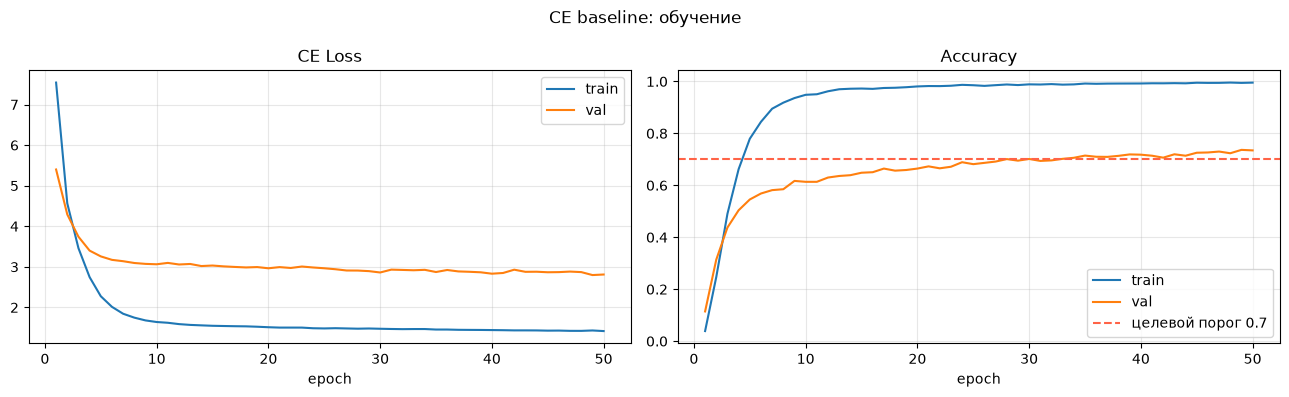

In [14]:
epochs_range = range(1, len(history_ce['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history_ce['train_loss'], label='train')
axes[0].plot(epochs_range, history_ce['val_loss'],   label='val')
axes[0].set_title('CE Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs_range, history_ce['train_acc'], label='train')
axes[1].plot(epochs_range, history_ce['val_acc'],   label='val')
axes[1].axhline(0.7, color='tomato', ls='--', label='целевой порог 0.7')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('CE baseline: обучение')
plt.tight_layout(); plt.show()


**Результат CE baseline:** 0.7365 переобучения нет


##  ArcFace: реализация головы

Теория и вывод формулы разобраны в файле задания. Вместо обычного
`Linear`- классификатора эмбеддинги и веса классов нормализуются на единичную
сферу, угол между ними получает  отступ $m$, а итоговые логиты
масштабируются коэффициентом $s$ перед подачей в обычный `CrossEntropyLoss`.

$$
\text{logit}_j =
\begin{cases}
s\cdot\cos(\theta_j + m), & j = y_i \\
s\cdot\cos(\theta_j), & j \ne y_i
\end{cases}
$$




In [15]:
class ArcMarginHead(nn.Module):
    
    def __init__(self, emb_dim: int, num_classes: int, s: float = 32.0, m: float = 0.0):
        super().__init__()
        self.num_classes = num_classes
        self.s = float(s)

        self.center = nn.Parameter(torch.empty(num_classes, emb_dim))
        nn.init.xavier_normal_(self.center)

        self.set_margin(m)

    def set_margin(self, m: float):
        # Меняет margin на лету 
        self.m = float(m)
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        x = F.normalize(embeddings, dim=1)
        w = F.normalize(self.center, dim=1)

        cosine = F.linear(x, w).clamp(-1.0 + 1e-7, 1.0 - 1e-7) 
        sine   = torch.sqrt(1.0 - cosine.pow(2))
        
        phi = cosine * self.cos_m - sine * self.sin_m             

        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        logits  = one_hot * phi + (1.0 - one_hot) * cosine
        
        return logits * self.s

### Плавный margin

Если сразу включить полный margin ($m=0.5$), обучение на старте часто
расходится: эмбеддинги ещё не сформированы, а штраф уже жёсткий. Поэтому
margin увеличивается линейно от 0 до целевого значения в течение первых
эпох.


In [16]:
def margin_warmup(epoch: int, warmup_epochs: int = 8, m_max: float = 0.5) -> float:
    if epoch >= warmup_epochs:
        return m_max
    return m_max * (epoch / warmup_epochs)



for e in [0, 1, 4, 8, 12]:
    print(f'epoch={e:2d}  m={margin_warmup(e):.3f}')


epoch= 0  m=0.000
epoch= 1  m=0.062
epoch= 4  m=0.250
epoch= 8  m=0.500
epoch=12  m=0.500


## Обучение ArcFace

In [18]:
N_EPOCHS_ARC   = 50
WARMUP_EPOCHS  = 10
ARC_S          = 32.0
ARC_M_MAX      = 0.5

model_arc = FaceBackbone(emb_dim=EMB_DIM, pretrained=True).to(device)
arc_head  = ArcMarginHead(EMB_DIM, NUM_CLASSES, s=ARC_S, m=0.0).to(device)

criterion_arc = nn.CrossEntropyLoss()
optimizer_arc = torch.optim.AdamW([
    {'params': model_arc.net.parameters(),  'lr': 1e-4},
    {'params': model_arc.neck.parameters(), 'lr': 1e-3},
    {'params': arc_head.parameters(),       'lr': 1e-3},
], weight_decay=5e-4)

history_arc = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_arc = 0.0

for epoch in tqdm(range(N_EPOCHS_ARC)):
    arc_head.set_margin(margin_warmup(epoch, WARMUP_EPOCHS, ARC_M_MAX))

    tr_loss, tr_acc = run_epoch(model_arc, dl_train, criterion_arc, device,
                                optimizer=optimizer_arc, arc_head=arc_head)

    # На валидации margin убираем (m=0): нас интересует, насколько хорошо
    # разделены классы по чистому косинусу, без искусственного отступа
    m_train = arc_head.m
    arc_head.set_margin(0.0)
    va_loss, va_acc = run_epoch(model_arc, dl_val, criterion_arc, device, arc_head=arc_head)
    arc_head.set_margin(m_train)

    history_arc['train_loss'].append(tr_loss); history_arc['val_loss'].append(va_loss)
    history_arc['train_acc'].append(tr_acc);   history_arc['val_acc'].append(va_acc)

    if va_acc > best_val_acc_arc:
        best_val_acc_arc = va_acc
        torch.save({'backbone': model_arc.state_dict(),
                    'head': arc_head.state_dict()}, '../models_weight/arcface_best.pt')

    print(f'[ArcFace] epoch {epoch+1:2d}/{N_EPOCHS_ARC}  m={m_train:.3f}  '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}  |  '
          f'val_loss={va_loss:.4f} acc={va_acc:.4f}')

print(f'\nЛучший val accuracy (ArcFace): {best_val_acc_arc:.4f}')


  0%|          | 0/50 [00:00<?, ?it/s]

[ArcFace] epoch  1/50  m=0.000  train_loss=7.0500 acc=0.0545  |  val_loss=4.7778 acc=0.1490
[ArcFace] epoch  2/50  m=0.050  train_loss=4.8542 acc=0.1324  |  val_loss=3.4688 acc=0.3200
[ArcFace] epoch  3/50  m=0.100  train_loss=4.5844 acc=0.1639  |  val_loss=2.7885 acc=0.4415
[ArcFace] epoch  4/50  m=0.150  train_loss=4.7049 acc=0.1704  |  val_loss=2.3586 acc=0.5240
[ArcFace] epoch  5/50  m=0.200  train_loss=4.9634 acc=0.1615  |  val_loss=2.0770 acc=0.5820
[ArcFace] epoch  6/50  m=0.250  train_loss=5.3968 acc=0.1393  |  val_loss=1.8777 acc=0.6320
[ArcFace] epoch  7/50  m=0.300  train_loss=5.9032 acc=0.1232  |  val_loss=1.7346 acc=0.6695
[ArcFace] epoch  8/50  m=0.350  train_loss=6.5081 acc=0.1001  |  val_loss=1.6403 acc=0.6825
[ArcFace] epoch  9/50  m=0.400  train_loss=7.2097 acc=0.0844  |  val_loss=1.5589 acc=0.7085
[ArcFace] epoch 10/50  m=0.450  train_loss=7.9318 acc=0.0664  |  val_loss=1.5225 acc=0.7170
[ArcFace] epoch 11/50  m=0.500  train_loss=8.7484 acc=0.0452  |  val_loss=1.4686

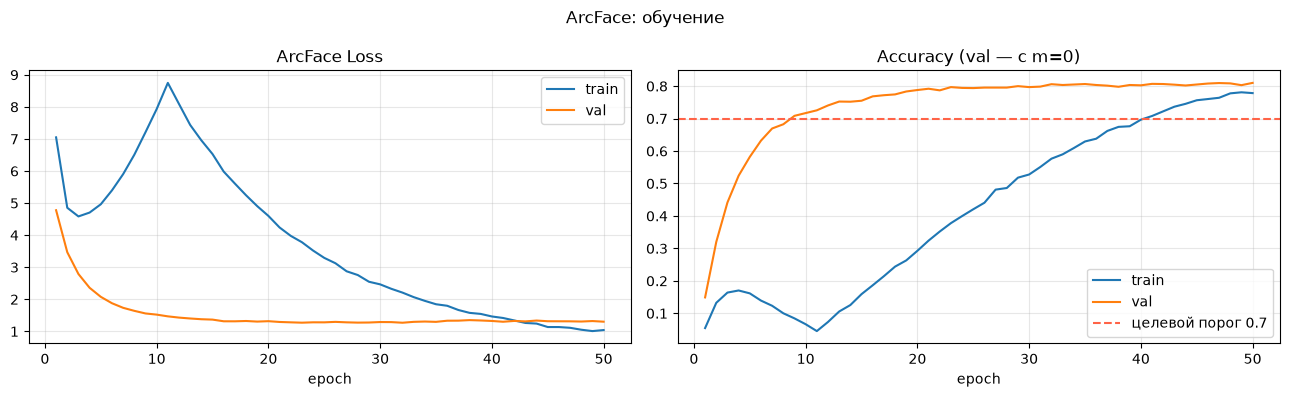

In [19]:
epochs_range = range(1, len(history_arc['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history_arc['train_loss'], label='train')
axes[0].plot(epochs_range, history_arc['val_loss'],   label='val')
axes[0].set_title('ArcFace Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs_range, history_arc['train_acc'], label='train')
axes[1].plot(epochs_range, history_arc['val_acc'],   label='val')
axes[1].axhline(0.7, color='tomato', ls='--', label='целевой порог 0.7')
axes[1].set_title('Accuracy (val — с m=0)'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('ArcFace: обучение')
plt.tight_layout(); plt.show()


**Результат ArcFace:** 0.81
`best_val_acc_arc`.  margin-warmup-а -
пока $m$ маленький, обучение похоже на CE; по мере роста margin loss 
временно подрастает, а затем
снова снижается.


##  Сравнение CE и ArcFace: пространство эмбеддингов

Числовая accuracy показывает, насколько хорошо сеть **классифицирует**
уже виденные классы. Но ArcFace создавался ради другого свойства -
компактности эмбеддингов внутри класса и разделимости между классами.
Проверим это визуально через пространство эмбеддингов и через распределение косинусных
сходств "свой/чужой".


In [20]:
from sklearn.manifold import TSNE

@torch.no_grad()
def collect_embeddings(backbone_fn, loader, device, max_samples=1200):
    """Прогоняет loader через backbone_fn (без головы) и собирает эмбеддинги."""
    embs, labels = [], []
    n = 0
    for xb, yb in loader:
        emb = backbone_fn(xb.to(device))
        emb = F.normalize(emb, dim=1)
        embs.append(emb.cpu().numpy())
        labels.append(yb.numpy())
        n += xb.size(0)
        if n >= max_samples:
            break
    return np.concatenate(embs)[:max_samples], np.concatenate(labels)[:max_samples]


model_ce.eval(); model_arc.eval()

emb_ce,  lab_ce  = collect_embeddings(lambda x: model_ce.backbone(x), dl_val, device)
emb_arc, lab_arc = collect_embeddings(lambda x: model_arc(x),         dl_val, device)

print('CE embeddings:     ', emb_ce.shape)
print('ArcFace embeddings:', emb_arc.shape)


CE embeddings:      (1200, 512)
ArcFace embeddings: (1200, 512)


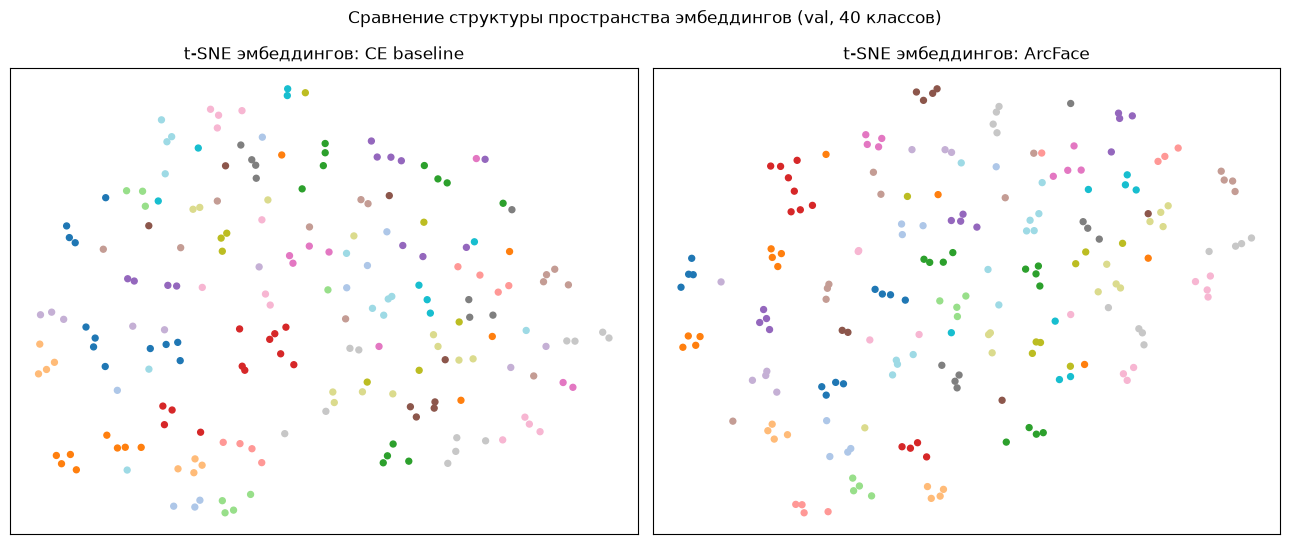

In [21]:
def subset_for_tsne(embs, labels, n_classes=50):
    keep_classes = sorted(set(labels))[:n_classes]
    mask = np.isin(labels, keep_classes)
    return embs[mask], labels[mask]

emb_ce_sub,  lab_ce_sub  = subset_for_tsne(emb_ce,  lab_ce)
emb_arc_sub, lab_arc_sub = subset_for_tsne(emb_arc, lab_arc)

tsne_ce  = TSNE(n_components=2, perplexity=25, random_state=SEED).fit_transform(emb_ce_sub)
tsne_arc = TSNE(n_components=2, perplexity=25, random_state=SEED).fit_transform(emb_arc_sub)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc0 = axes[0].scatter(tsne_ce[:,0],  tsne_ce[:,1],  c=lab_ce_sub,  cmap='tab20', s=18)
axes[0].set_title('t-SNE эмбеддингов: CE baseline')
sc1 = axes[1].scatter(tsne_arc[:,0], tsne_arc[:,1], c=lab_arc_sub, cmap='tab20', s=18)
axes[1].set_title('t-SNE эмбеддингов: ArcFace')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Сравнение структуры пространства эмбеддингов (val, 40 классов)')
plt.tight_layout(); plt.show()


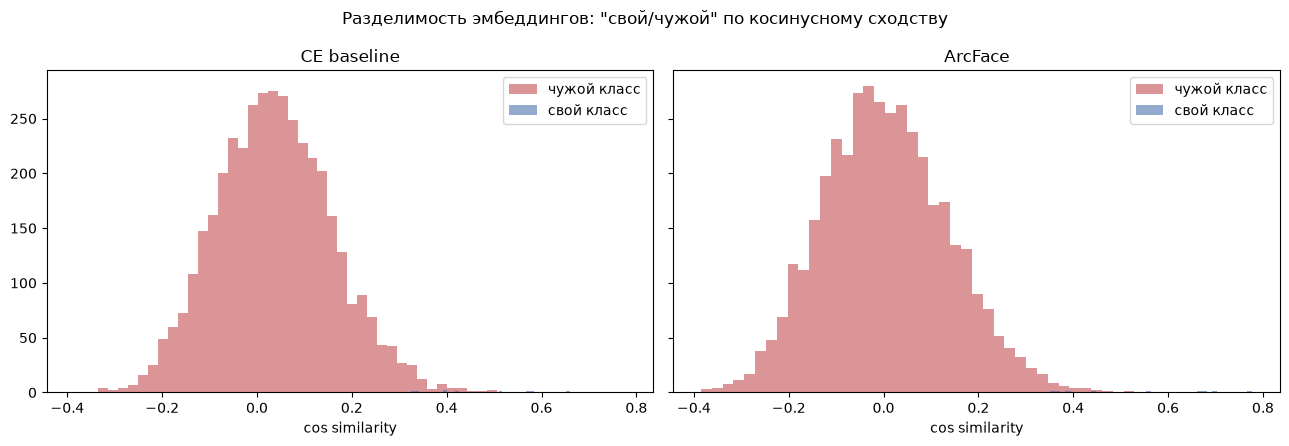

Разрыв (mean_same - mean_diff), CE:      0.4281
Разрыв (mean_same - mean_diff), ArcFace: 0.5439
(чем больше разрыв - тем лучше эмбеддинги разделяют "своих" и "чужих")


In [22]:
# Распределение косинусных сходств: пары "свой класс" vs "чужой класс"
def pairwise_cosine_stats(embs, labels, n_pairs=4000, seed=SEED):
    rng_ = np.random.RandomState(seed)
    n = len(embs)
    idx_a = rng_.randint(0, n, size=n_pairs)
    idx_b = rng_.randint(0, n, size=n_pairs)
    valid = idx_a != idx_b
    idx_a, idx_b = idx_a[valid], idx_b[valid]

    sims = (embs[idx_a] * embs[idx_b]).sum(axis=1)  # эмбеддинги уже L2-нормированы
    same = labels[idx_a] == labels[idx_b]
    return sims[same], sims[~same]


same_ce,  diff_ce  = pairwise_cosine_stats(emb_ce,  lab_ce)
same_arc, diff_arc = pairwise_cosine_stats(emb_arc, lab_arc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

axes[0].hist(diff_ce, bins=40, alpha=0.6, label='чужой класс', color='lightcoral')
axes[0].hist(same_ce, bins=40, alpha=0.6, label='свой класс',  color='steelblue')
axes[0].set_title('CE baseline'); axes[0].set_xlabel('cos similarity'); axes[0].legend()

axes[1].hist(diff_arc, bins=40, alpha=0.6, label='чужой класс', color='lightcoral')
axes[1].hist(same_arc, bins=40, alpha=0.6, label='свой класс',  color='steelblue')
axes[1].set_title('ArcFace'); axes[1].set_xlabel('cos similarity'); axes[1].legend()

plt.suptitle('Разделимость эмбеддингов: "свой/чужой" по косинусному сходству')
plt.tight_layout(); plt.show()

def gap(same, diff):
    return same.mean() - diff.mean()

print(f'Разрыв (mean_same - mean_diff), CE:      {gap(same_ce, diff_ce):.4f}')
print(f'Разрыв (mean_same - mean_diff), ArcFace: {gap(same_arc, diff_arc):.4f}')
print('(чем больше разрыв - тем лучше эмбеддинги разделяют "своих" и "чужих")')

## 8. Отчёт: CE vs ArcFace


1. **Accuracy.** Обе модели достигли ≥ 0.7 на val. На arcface показал лучшее качество 0.81.
2. **Структура эмбеддингов.** ArcFace, как правило, формирует более плотные
   и более разделённые кластеры на пространстве эмбеддингов, потому что явно штрафует малый
   угловой отступ между разными классами, в то время как CE такого
   ограничения не накладывает.
3. **Разрыв cos(свой)/cos(чужой).** Это ключевая метрика, ради которой и
   существует ArcFace: чем он больше, тем надёжнее можно будет отличать
   "своего" человека от "чужого" по порогу косинусного сходства - то есть
   тем лучше эмбеддинги подходят для **верификации** .
